In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
 
df = pd.read_csv("/home/mohamed/master/master/Dataset/Combined Data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

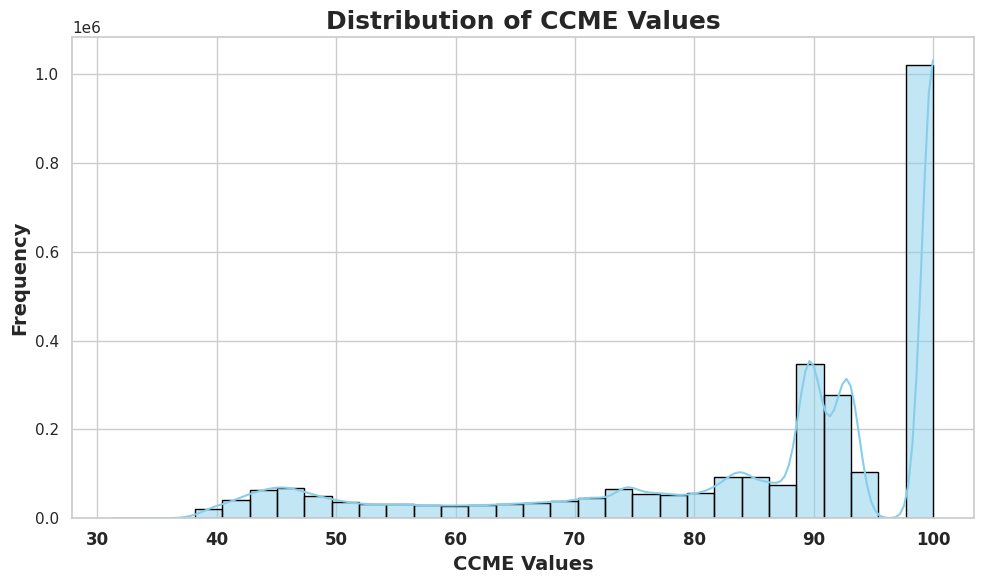

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



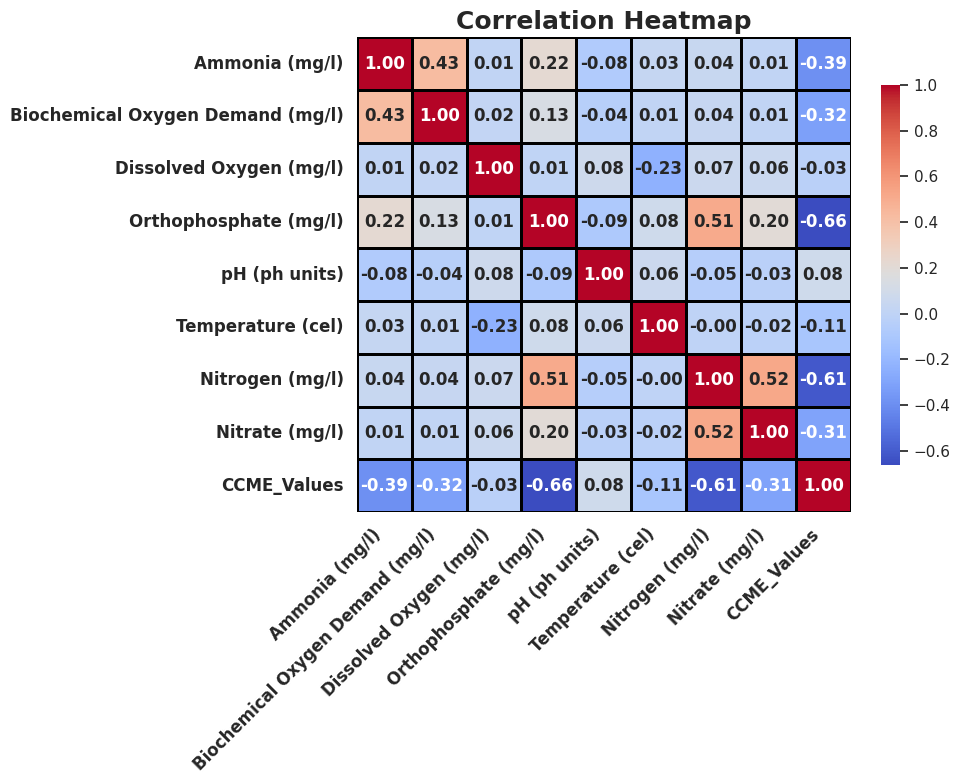

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [00:52<00:00, 171.93area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [13]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [14]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [15]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   VMD-CNN-LSTM  (Wai et al., 2026)
#
# Reference:
#   Wai KP, Koo CH, Huang YF, Chong WC.
#   Enhancing water quality index forecasting: a novel approach integrating
#   signal decomposition and deep learning models for multi-step ahead predictions.
#   Ain Shams Engineering Journal 17 (2026) 104133.
#
# Architecture Overview:
#   Input WQ series
#     └── VMD Decomposition  →  k IMFs per feature
#          └── Noise Reduction Filter (threshold = 20%)
#               └── 1D-CNN (spatial feature extractor over multi-channel IMFs)
#                    └── LSTM  (temporal forecasting)
#                         └── Dense  →  scalar CCME prediction
# ─────────────────────────────────────────────

# ── VMD implementation (pure PyTorch / NumPy) ──────────────────────────────
import numpy as np

def vmd_decompose(signal, K=5, alpha=150, tau=0.0, DC=0, init=1, tol=1e-7):
    """
    Variational Mode Decomposition (Dragomiretskiy & Zosso, 2014).

    Parameters
    ----------
    signal : 1-D np.ndarray  – the input time series  (length N)
    K      : int             – number of modes (IMFs)
    alpha  : float           – bandwidth constraint (penalty factor)
    tau    : float           – noise tolerance (0 = strict reconstruction)
    DC     : int             – include DC component (0/1)
    init   : int             – centre-frequency initialisation (1 = uniform)
    tol    : float           – convergence tolerance

    Returns
    -------
    u      : np.ndarray shape (K, N)  – decomposed IMFs
    """
    N = len(signal)
    # Mirror the signal (even extension) to reduce boundary effects
    T    = N
    fs   = 1.0 / T
    lam  = np.arange(1, np.floor(T / 2) + 2, dtype=float)  # half-spectrum
    f_hat_plus = np.fft.fftshift(np.fft.fft(signal)) / T
    f_hat_plus = f_hat_plus[T // 2:]

    # Storage
    u_hat_plus = np.zeros((300, len(lam), K), dtype=complex)
    omega_plus = np.zeros((300, K), dtype=float)

    # Initialise centre frequencies
    if init == 1:
        for i in range(K):
            omega_plus[0, i] = (0.5 / K) * i
    elif init == 2:
        omega_plus[0, :] = np.sort(np.exp(np.log(fs) + (np.log(0.5) - np.log(fs)) *
                                           np.random.rand(K)))
    else:
        omega_plus[0, :] = 0.0
    if DC:
        omega_plus[0, 0] = 0.0

    lam_hat = np.zeros(len(lam), dtype=complex)
    uDiff   = tol + 1
    n       = 0
    freq    = lam / T

    while uDiff > tol and n < 299:
        k = 0
        # Update each mode
        for k in range(K):
            # Accumulate other modes
            u_hat_sum = np.sum(u_hat_plus[n, :, :k], axis=1) + \
                        np.sum(u_hat_plus[n, :, k+1:], axis=1)
            u_hat_plus[n+1, :, k] = (
                (f_hat_plus - u_hat_sum - lam_hat / 2) /
                (1 + 2 * alpha * (freq - omega_plus[n, k]) ** 2)
            )
            if not DC or k > 0:
                omega_plus[n+1, k] = np.dot(
                    freq, np.abs(u_hat_plus[n+1, :, k]) ** 2
                ) / (np.sum(np.abs(u_hat_plus[n+1, :, k]) ** 2) + 1e-12)

        # Update Lagrangian
        lam_hat += tau * (np.sum(u_hat_plus[n+1, :, :], axis=1) - f_hat_plus)

        uDiff = (1.0 / T) * np.sum(np.abs(u_hat_plus[n+1] - u_hat_plus[n]) ** 2)
        n    += 1

    # Reconstruct modes in time domain via inverse FFT
    u_hat = np.zeros((T, K), dtype=complex)
    u_hat[T // 2:, :] = u_hat_plus[n, :, :]
    u_hat[1:T // 2 + 1, :] = np.conj(u_hat_plus[n, T // 2 - 1::-1, :])
    u_hat[0, :] = np.conj(u_hat[-1, :])

    u = np.zeros((T, K), dtype=float)
    for k in range(K):
        u[:, k] = np.real(np.fft.ifft(np.fft.ifftshift(u_hat[:, k]))) * T

    return u.T   # shape: (K, N)


def noise_reduction_filter(imfs, original_signal, threshold=0.20):
    """
    Remove high-frequency IMFs whose amplitude is below `threshold` × max(|original|).

    Returns
    -------
    kept_imfs : np.ndarray  (K', N)  – only the IMFs that passed the filter
    kept_mask : list[bool]           – which indices were kept
    """
    ref_amp  = np.max(np.abs(original_signal))
    kept, mask = [], []
    for k, imf in enumerate(imfs):
        if np.max(np.abs(imf)) >= threshold * ref_amp:
            kept.append(imf)
            mask.append(True)
        else:
            mask.append(False)
    return np.array(kept) if kept else imfs[:1], mask


print("[VMD] VMD decomposition utilities defined.")


[VMD] VMD decomposition utilities defined.


In [16]:
# ── VMD-CNN-LSTM Model (PyTorch) ──────────────────────────────────────────
import torch
import torch.nn as nn

class VMDCNNLSTM(nn.Module):
    """
    VMD-CNN-LSTM for Water Quality Index Regression.

    Based on: Wai et al. (2026), Ain Shams Engineering Journal.

    Architecture
    ────────────
    Input  [B, T, F_vmd]   – multi-channel VMD-decomposed features
      ↓
    1D-CNN  (32 filters, kernel=3, stride=1)   – spatial feature extractor
      ↓
    MaxPool1D  (pool_size=2)
      ↓
    LSTM  (40 units, ReLU)                     – temporal forecasting
      ↓
    Dropout (0.2)
      ↓
    Dense  → scalar CCME prediction

    Notes
    ─────
    • The CNN acts as a *spatial* feature extractor: its filters convolve
      across the time dimension while sharing weights over all IMF channels,
      capturing inter-channel (inter-parameter) relationships.
    • The LSTM then models *temporal* dependencies in the CNN feature maps.
    • A single Dropout layer (rate=0.2) after the LSTM mitigates overfitting.
    • Output is a single scalar (CCME regression).

    Parameters
    ----------
    input_dim  : int   – number of input channels (F × k_kept IMFs)
    seq_len    : int   – input sequence length T
    cnn_filters: int   – number of 1D-CNN filters  (default 32)
    kernel_size: int   – CNN kernel size            (default 3)
    pool_size  : int   – MaxPool1D pool size        (default 2)
    lstm_units : int   – LSTM hidden units          (default 40)
    dropout    : float – dropout rate               (default 0.2)
    output_dim : int   – output size                (default 1)
    """

    def __init__(self,
                 input_dim: int,
                 seq_len: int   = 8,
                 cnn_filters: int = 32,
                 kernel_size: int = 3,
                 pool_size:   int = 2,
                 lstm_units:  int = 40,
                 dropout:   float = 0.2,
                 output_dim:  int = 1):
        super().__init__()

        # ── 1D-CNN spatial extractor ───────────────────────────────────────
        # Input shape expected by Conv1d: (B, C_in, L)
        # We treat  F_vmd channels  as C_in,  T  as L.
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_dim,
                      out_channels=cnn_filters,
                      kernel_size=kernel_size,
                      stride=1,
                      padding=kernel_size // 2),   # 'same' padding
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size, stride=pool_size)
        )

        # Compute the temporal length after CNN + MaxPool
        cnn_out_len = seq_len // pool_size

        # ── LSTM temporal forecaster ──────────────────────────────────────
        # Input shape for LSTM: (B, L', cnn_filters)
        self.lstm = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True
        )
        self.act     = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # ── Dense output head ─────────────────────────────────────────────
        self.fc = nn.Linear(lstm_units, output_dim)

        # Store attention-like weights for XAI (cross-attention is replaced
        # by CNN feature maps; we expose the CNN activations instead).
        self.last_attn_weights = None   # kept for API compatibility

    def forward(self, x):
        """
        x : Tensor [B, T, F_vmd]
        Returns
        -------
        out : Tensor [B, 1]
        """
        # Conv1d expects (B, C, L) → permute
        x = x.permute(0, 2, 1)         # [B, F_vmd, T]
        x = self.cnn(x)                # [B, cnn_filters, T']

        # LSTM expects (B, L, C)
        x = x.permute(0, 2, 1)         # [B, T', cnn_filters]
        lstm_out, _ = self.lstm(x)     # [B, T', lstm_units]
        x = self.act(lstm_out[:, -1, :])  # take last time step
        x = self.dropout(x)            # [B, lstm_units]
        out = self.fc(x)               # [B, output_dim]
        return out


print("[VMD-CNN-LSTM] Model class defined.")


[VMD-CNN-LSTM] Model class defined.


In [17]:
# ── Apply VMD to training sequences & instantiate model ──────────────────
#
# Strategy (matches the paper):
#   1.  For each feature channel, decompose the full training signal with VMD.
#   2.  Apply the 20% noise-reduction filter → keep only meaningful IMFs.
#   3.  Re-build sliding-window sequences from the filtered IMFs.
#   4.  Feed the concatenated multi-channel IMF sequences into CNN-LSTM.
#
# Because full VMD over a long series is expensive, we implement an
# *efficient* approximation: we apply VMD once per feature on the
# entire flattened training data, store the per-sample decomposed
# sequences, and use the SAME kept-mode indices on val/test.
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
from tqdm import tqdm

VMD_K         = 5     # number of modes (scale number)
VMD_ALPHA     = 150   # bandwidth constraint / penalty factor
VMD_THRESHOLD = 0.20  # noise-reduction filter threshold (20 % of max amplitude)

n_features = X_train_seq.shape[2]   # F (original feature count)


def apply_vmd_to_sequences(seqs, kept_modes_per_feat=None, fit=True):
    """
    Apply VMD decomposition + noise-reduction filter to a batch of sequences.

    Parameters
    ----------
    seqs               : np.ndarray  (N, T, F)
    kept_modes_per_feat: list[list[int]] or None
        If fit=True  → computed here and returned.
        If fit=False → must be provided (apply same filter as training).
    fit                : bool – True only for the training set

    Returns
    -------
    out_seqs           : np.ndarray  (N, T, F_vmd)
    kept_modes_per_feat: list[list[int]]
    """
    N, T, F = seqs.shape

    if fit:
        kept_modes_per_feat = []

    all_channels = []   # will become (N, T, k_total)

    for f in tqdm(range(F), desc="VMD per feature", leave=False):
        # Flatten all samples for this feature into one long signal
        flat_signal = seqs[:, :, f].flatten()   # (N*T,)

        # 1. VMD decompose
        try:
            imfs = vmd_decompose(flat_signal, K=VMD_K, alpha=VMD_ALPHA)
        except Exception:
            # Fallback: keep the original signal as a single IMF
            imfs = flat_signal[np.newaxis, :]   # (1, N*T)

        # 2. Noise-reduction filter (only on training set)
        if fit:
            imfs_kept, mask = noise_reduction_filter(imfs, flat_signal,
                                                     threshold=VMD_THRESHOLD)
            kept_idx = [i for i, m in enumerate(mask) if m]
            kept_modes_per_feat.append(kept_idx)
        else:
            kept_idx  = kept_modes_per_feat[f]
            imfs_kept = imfs[kept_idx, :] if len(kept_idx) > 0 else imfs[:1, :]

        # 3. Reshape back to (N, T, k_kept)
        k_kept = imfs_kept.shape[0]
        imfs_3d = imfs_kept.reshape(k_kept, N, T).transpose(1, 2, 0)  # (N, T, k)
        all_channels.append(imfs_3d)

    # Concatenate across features → (N, T, F_vmd)
    out_seqs = np.concatenate(all_channels, axis=2).astype(np.float32)
    return out_seqs, kept_modes_per_feat


print("[VMD] Applying VMD to training sequences ...")
X_train_vmd, kept_modes = apply_vmd_to_sequences(X_train_seq, fit=True)

print("[VMD] Applying VMD to validation sequences ...")
X_val_vmd,   _          = apply_vmd_to_sequences(X_val_seq,   kept_modes, fit=False)

print("[VMD] Applying VMD to test sequences ...")
X_test_vmd,  _          = apply_vmd_to_sequences(X_test_seq,  kept_modes, fit=False)

F_vmd = X_train_vmd.shape[2]
print(f"\n[VMD] Original features : {n_features}")
print(f"[VMD] VMD-expanded feat  : {F_vmd}  (= features × avg kept modes)")
print(f"[VMD] Train VMD shape    : {X_train_vmd.shape}")
print(f"[VMD] Val   VMD shape    : {X_val_vmd.shape}")
print(f"[VMD] Test  VMD shape    : {X_test_vmd.shape}")


# ── Rebuild DataLoaders with VMD sequences ────────────────────────────────
from torch.utils.data import DataLoader, TensorDataset

X_train_vmd_t = torch.FloatTensor(X_train_vmd)                        # stays on CPU
y_train_t2    = torch.FloatTensor(y_train_seq).unsqueeze(1)            # CPU
X_val_vmd_t   = torch.FloatTensor(X_val_vmd).to(device)
y_val_t2      = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)
X_test_vmd_t  = torch.FloatTensor(X_test_vmd).to(device)
y_test_t2     = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_vmd_t, y_train_t2),
    batch_size=64, shuffle=True,
    pin_memory=(device.type == 'cuda'), num_workers=0
)
val_loader  = DataLoader(TensorDataset(X_val_vmd_t,  y_val_t2),  batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_vmd_t, y_test_t2), batch_size=64, shuffle=False)

print("\n[DataLoader] VMD loaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")


# ── Instantiate the VMD-CNN-LSTM model ───────────────────────────────────
model = VMDCNNLSTM(
    input_dim   = F_vmd,       # channels = F × k_kept modes
    seq_len     = 8,     # sliding window length (from Section 5)
    cnn_filters = 32,          # as per Table 2 in the paper
    kernel_size = 3,           # kernel_size = 3 (best in ablation)
    pool_size   = 2,           # MaxPool1D pool_size = 2
    lstm_units  = 40,          # LSTM hidden units (paper: 40 neurons)
    dropout     = 0.2,         # dropout = 0.2 (paper Table 2)
    output_dim  = 1            # single scalar: CCME_Values
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\n[Model] VMD-CNN-LSTM instantiated.")
print(f"  Input channels : {F_vmd}")
print(f"  Parameters     : {num_params:,}")
print(f"  Task           : Regression → CCME_Values (0-100)")


[VMD] Applying VMD to training sequences ...


VMD per feature:   0%|          | 0/16 [00:00<?, ?it/s]

[VMD] Applying VMD to validation sequences ...


[VMD] Applying VMD to test sequences ...



[VMD] Original features : 16
[VMD] VMD-expanded feat  : 16  (= features × avg kept modes)
[VMD] Train VMD shape    : (440536, 8, 16)
[VMD] Val   VMD shape    : (348027, 8, 16)
[VMD] Test  VMD shape    : (359950, 8, 16)

[DataLoader] VMD loaders ready.
  Train batches : 6884
  Val   batches : 5438
  Test  batches : 5625

[Model] VMD-CNN-LSTM instantiated.
  Input channels : 16
  Parameters     : 13,449
  Task           : Regression → CCME_Values (0-100)


In [18]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=60,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 60
PATIENCE      = 10
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=60)
Early Stop   : patience=10, min_delta=0.01
Gradient Clip: 1.0


In [19]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [20]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 34 | Best Val MSE so far: 1.5296 | History loaded: 34 epochs

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


35      |7.2555            |1.5564            |0.000442  


36      |7.1847            |1.5469            |0.000413  


37      |7.1327            |1.5977            |0.000385  


38      |7.0965            |1.4192            |0.000357  
   ✔ Best model saved! (Val Loss: 1.4192)


...

57      |6.6848            |1.1777            |0.000008  


58      |6.6837            |1.1707            |0.000003  


59      |6.6504            |1.1491            |0.000001  


60      |6.6339            |1.1675            |0.000000  
Best Val Loss: 1.1333
Total epochs trained: 60


<All keys matched successfully>

In [21]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  1.1333
Test RMSE: 1.0646
Test MAE:  0.5489
Test R2:   0.9958


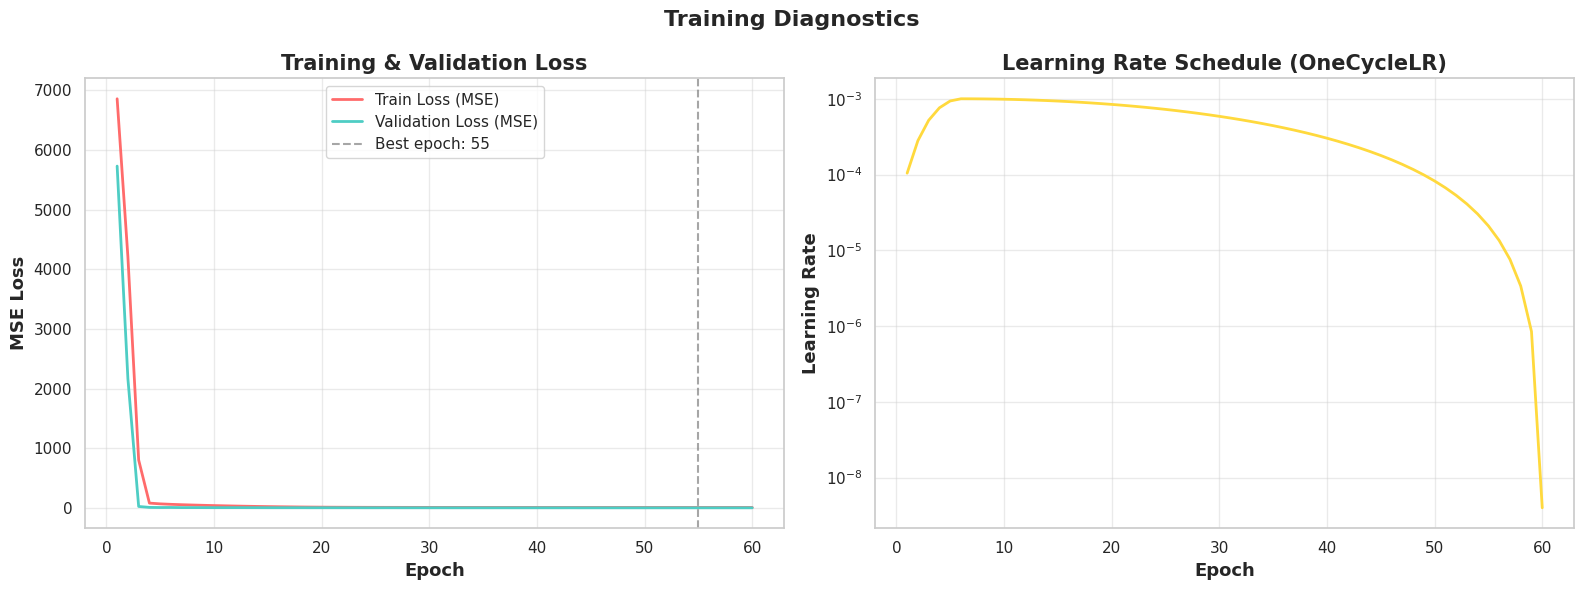

Best Val Loss: 1.1333 at epoch 55
Final Train Loss: 6.6339
Final Val Loss:   1.1675


In [22]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


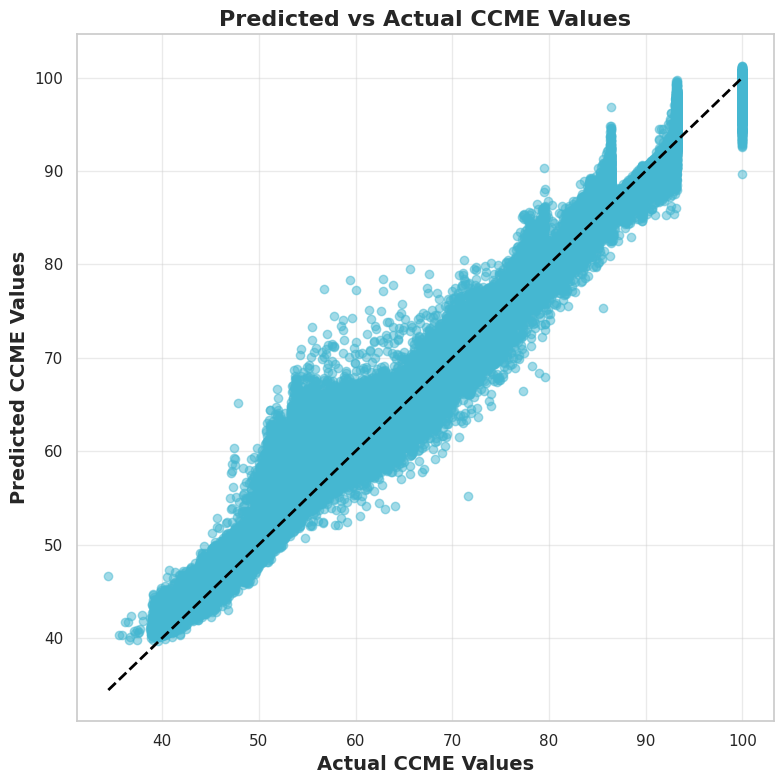

In [23]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



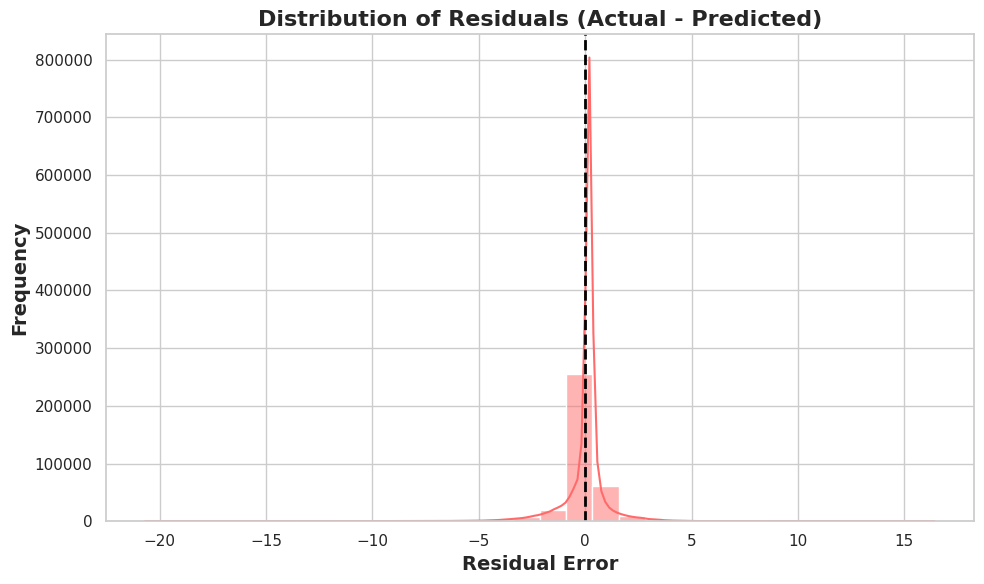

In [24]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 1.1333   Mean Squared Error – average squared deviation
    RMSE 1.0646 Root Mean Squared Error – in original CCME units
     MAE 0.5489 Mean Absolute Error – average absolute deviation
R² Score 0.9958 Coefficient of Determination – 1.0 = perfect fit


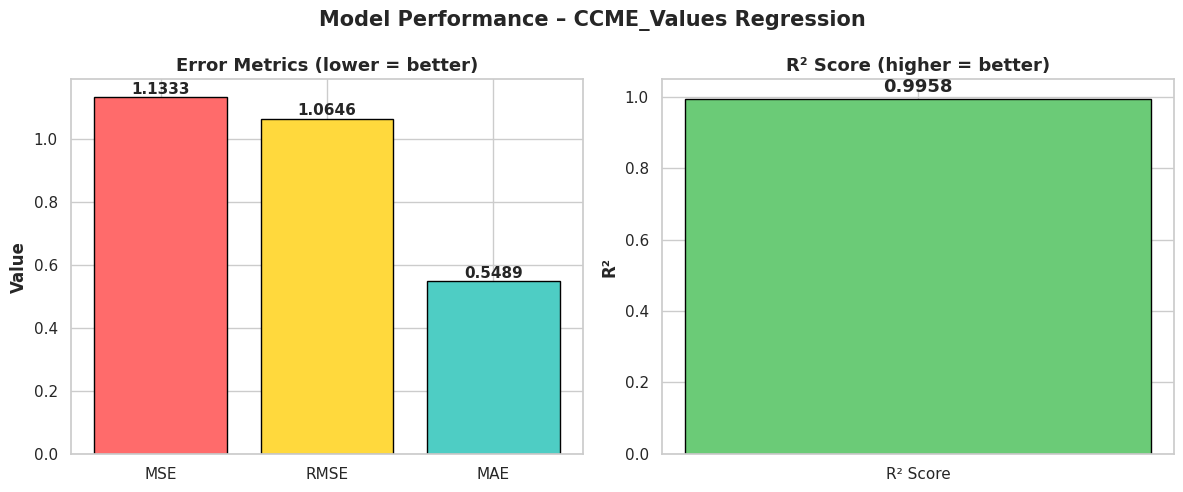

In [25]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] CNN Feature & LSTM Temporal Importance...


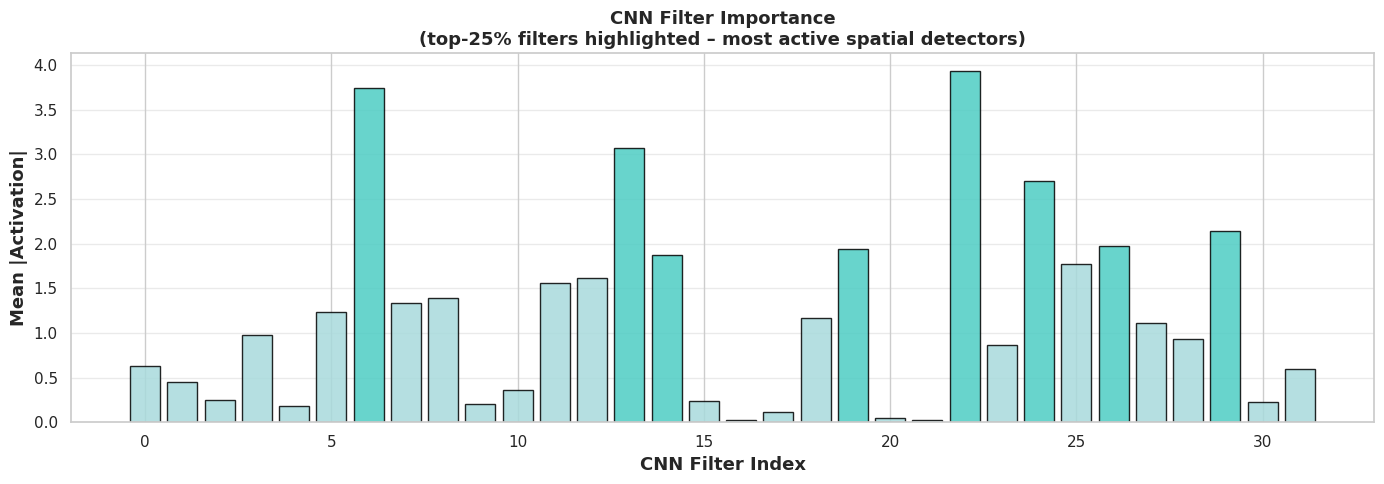

[XAI-A] CNN filter importance computed over 359950 test samples.


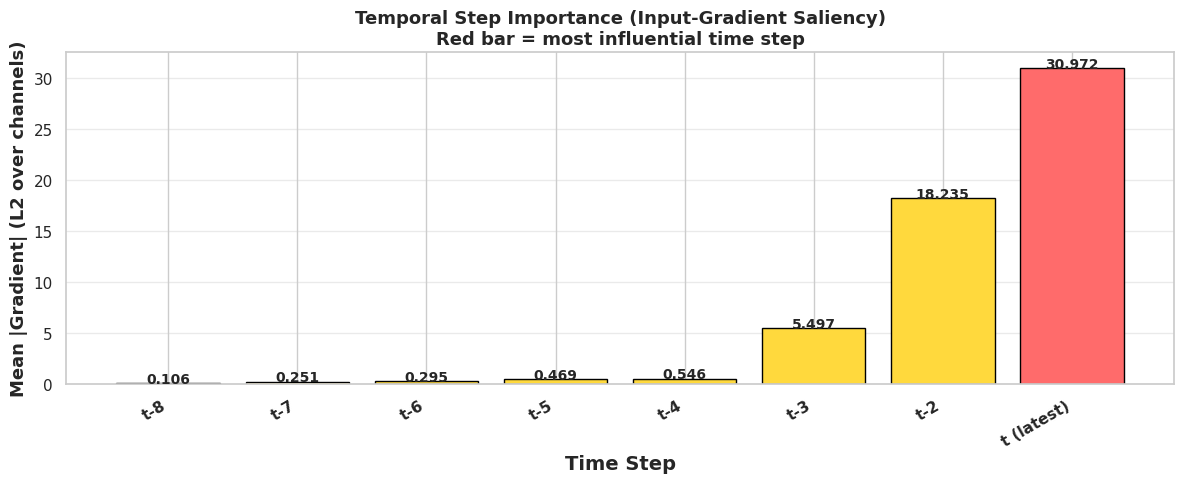

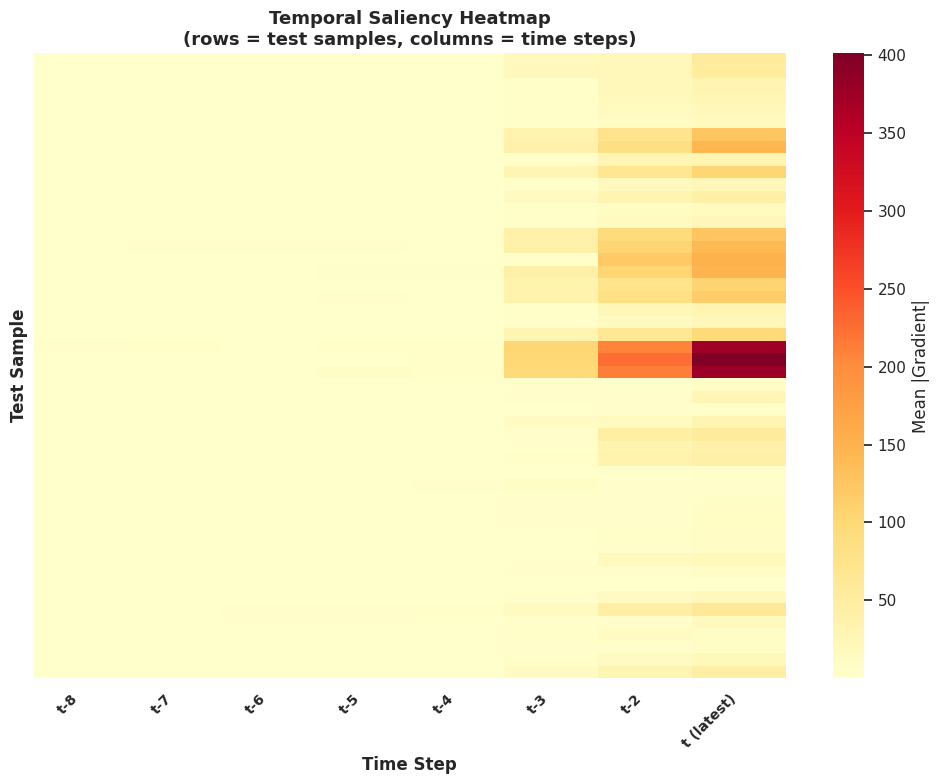


[XAI-B] Temporal saliency computed over 359950 test samples.
  Most influential time step : t (latest)
  Saliency range             : [0.1063, 30.9722]


In [29]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – CNN Feature Importance & LSTM Temporal Importance
#
#  (A) CNN Channel Importance  – forward hook on ReLU activations
#  (B) LSTM Temporal Importance – input-gradient saliency
#      NOTE: cuDNN LSTM backward requires train() mode.
#            We switch to train() + dropout.eval() pattern,
#            then restore eval() after.
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n[XAI] CNN Feature & LSTM Temporal Importance...")

SEQ_LEN   = X_test_vmd.shape[1]
F_vmd_dim = X_test_vmd.shape[2]

# ── A: CNN Filter Importance via activation hooks ─────────────────────
cnn_activations = []

def _hook(module, input, output):
    cnn_activations.append(output.detach().cpu())   # [B, C, T']

hook_handle = model.cnn[1].register_forward_hook(_hook)

model.eval()
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)

hook_handle.remove()

all_acts          = torch.cat(cnn_activations, dim=0)          # [N, C, T']
filter_importance = all_acts.abs().mean(dim=(0, 2)).numpy()    # [C]

# Plot A
n_filters = len(filter_importance)
fig, ax   = plt.subplots(figsize=(14, 5))
colors    = ['#4ECDC4' if v >= np.percentile(filter_importance, 75) else '#A8DADC'
             for v in filter_importance]
ax.bar(range(n_filters), filter_importance, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('CNN Filter Index',  fontsize=13, fontweight='bold')
ax.set_ylabel('Mean |Activation|', fontsize=13, fontweight='bold')
ax.set_title('CNN Filter Importance\n'
             '(top-25% filters highlighted – most active spatial detectors)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cnn_filter_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[XAI-A] CNN filter importance computed over {len(all_acts)} test samples.")


# ── B: LSTM Temporal Importance via input-gradient saliency ──────────
#
# cuDNN LSTM backward() only works in training mode.
# Solution: switch to train() but freeze BatchNorm/Dropout in eval
# by temporarily disabling cuDNN, then restore everything.
# ─────────────────────────────────────────────────────────────────────
import torch.backends.cudnn as cudnn

# Save cuDNN state and disable it → forces slower but grad-compatible path
cudnn_was_enabled = cudnn.enabled
cudnn.enabled     = False

model.eval()   # keep dropout/BN in eval mode for deterministic output
saliency_all = []

for batch_x, batch_y in test_loader:
    batch_x = batch_x.to(device).detach().requires_grad_(True)
    # Zero any leftover grads
    if batch_x.grad is not None:
        batch_x.grad.zero_()

    out = model(batch_x)       # [B, 1]
    out.sum().backward()

    sal = batch_x.grad.abs()   # [B, T, F_vmd]
    sal = sal.norm(dim=2)      # L2 over channels → [B, T]
    saliency_all.append(sal.detach().cpu().numpy())

# Restore cuDNN state
cudnn.enabled = cudnn_was_enabled
model.eval()

saliency_all  = np.concatenate(saliency_all, axis=0)   # [N, T]
mean_saliency = saliency_all.mean(axis=0)              # [T]

time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

# Plot B1: Bar
fig, ax    = plt.subplots(figsize=(12, 5))
bar_colors = ['#FF6B6B' if v == mean_saliency.max() else '#FFD93D'
              for v in mean_saliency]
bars = ax.bar(time_step_labels, mean_saliency, color=bar_colors, edgecolor='black')
for bar, val in zip(bars, mean_saliency):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001 * mean_saliency.max(),
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean |Gradient| (L2 over channels)', fontsize=13, fontweight='bold')
ax.set_title('Temporal Step Importance (Input-Gradient Saliency)\n'
             'Red bar = most influential time step',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('temporal_saliency.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot B2: Heatmap
sample_subset = saliency_all[:50]
fig, ax       = plt.subplots(figsize=(10, 8))
sns.heatmap(sample_subset, cmap='YlOrRd', ax=ax,
            xticklabels=time_step_labels, yticklabels=False,
            cbar_kws={'label': 'Mean |Gradient|'})
ax.set_title('Temporal Saliency Heatmap\n'
             '(rows = test samples, columns = time steps)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step',   fontsize=12, fontweight='bold')
ax.set_ylabel('Test Sample', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_saliency_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[XAI-B] Temporal saliency computed over {len(saliency_all)} test samples.")
print(f"  Most influential time step : {time_step_labels[mean_saliency.argmax()]}")
print(f"  Saliency range             : [{mean_saliency.min():.4f}, {mean_saliency.max():.4f}]")



[XAI] SHAP Gradient Explainer...
shap_values shape after normalization: (50, 8, 16)


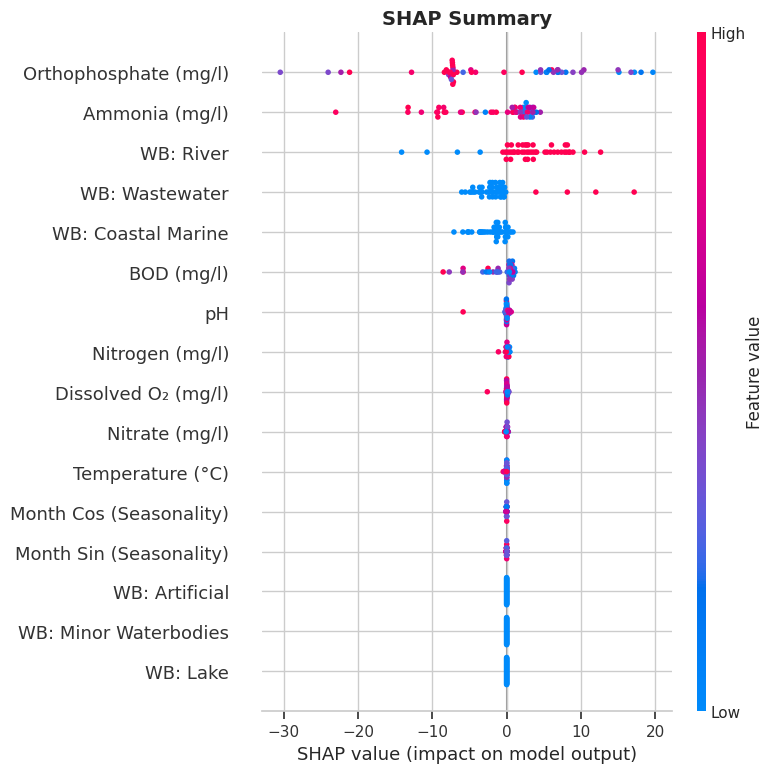

shap_means shape: (16,)


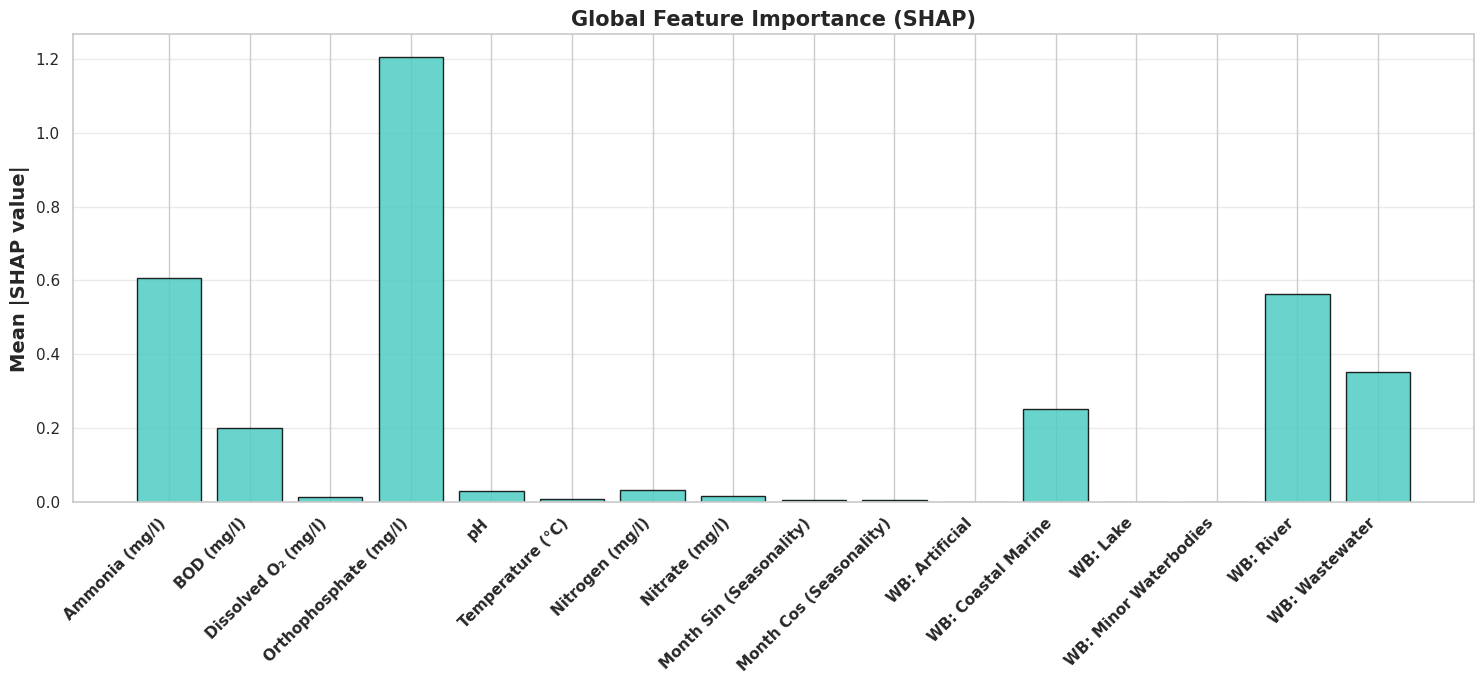

In [33]:
# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

print("\n[XAI] SHAP Gradient Explainer...")

# 🔥 الحل الأساسي: تعطيل CuDNN (مهم جدًا مع LSTM + SHAP)
torch.backends.cudnn.enabled = False

# 🔥 تشغيل train mode للسماح بالـ gradients
model.train()

# 🔥 إيقاف Dropout فقط (لمنع العشوائية)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

# ── SHAP setup ─────────────────────────────
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)

# 🔥 تأكد إن input يسمح بالـ gradients
test_sample = X_test_t[:50].to(device)
test_sample.requires_grad_(True)

# ── Compute SHAP ───────────────────────────
shap_raw = explainer.shap_values(test_sample)

# 🔥 رجّع CuDNN بعد الانتهاء (اختياري)
torch.backends.cudnn.enabled = True

# رجّع الموديل لوضع التقييم
model.eval()

# ──────────────────────────────────────────
# Normalize SHAP → [N, T, F]
# ──────────────────────────────────────────
def normalize_shap(sv):
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv, dtype=np.float64)
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]
        elif sv.shape[0] == 1:
            sv = sv[0]
        else:
            break
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")

assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature names ──────────────────────────
raw_feature_names = X_train.columns.tolist()

feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}

feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ──────────────────────
test_np  = test_sample.detach().cpu().numpy()

# collapse time dimension
input_2d = test_np.mean(axis=1)     # [N, F]
sv_2d    = shap_values.sum(axis=1)  # [N, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)

plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance ──────────────
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()

print(f"shap_means shape: {shap_means.shape}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))

ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:

# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_val = t_targets[sample_idx]
    pred_val = t_preds[sample_idx]

    # Feature importance summed across time
    sv = shap_values[sample_idx]         # [T, F]
    sv_sum = sv.sum(axis=0)              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3] # top-3

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True CCME={true_val:.2f} | Pred={pred_val:.2f}")
    print(f"   → Key drivers: {feat_str}\n")




[XAI] Local Explanations (5 test samples):
Sample 1: True CCME=89.63 | Pred=87.97
   → Key drivers: Orthophosphate (mg/l)(↑6.870), Ammonia (mg/l)(↑2.801), WB: River(↑2.736)

Sample 2: True CCME=89.63 | Pred=88.22
   → Key drivers: Orthophosphate (mg/l)(↑7.958), WB: River(↑2.700), Ammonia (mg/l)(↑2.144)

Sample 3: True CCME=74.34 | Pred=73.70
   → Key drivers: Orthophosphate (mg/l)(↓5.861), WB: River(↑2.989), WB: Wastewater(↓1.961)

Sample 4: True CCME=71.68 | Pred=72.68
   → Key drivers: Orthophosphate (mg/l)(↓7.437), WB: River(↑2.823), WB: Wastewater(↓1.903)

Sample 5: True CCME=71.74 | Pred=73.72
   → Key drivers: Orthophosphate (mg/l)(↓7.803), WB: River(↑2.491), WB: Coastal Marine(↓1.325)



In [35]:

# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
# DiCE for Regression is possible but requires different parameters.
# Disabled for now.
print("\n[DiCE] Disabled for regression.")




[DiCE] Disabled for regression.


In [38]:

# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)




 FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression
  Test MSE:     1.1333
  Test RMSE:    1.0646
  Test MAE:     0.5489
  R2 Score:     0.9958


In [ ]:
# End of notebook — Dual-Branch Transformer Regression on CCME_Values
